# L1 Baseline — XGBoost na TEXBAT features

**Setup:**
- **Train:** cleanStatic (456 rows, label=0) + ds3 (456 rows, ~346 spoofed) — łącznie 912 rows
- **Test:** ds7 (468 rows, OOD scenario — najtrudniejszy spoof, niewidziany w trainingu)
- **Features:** 23 numeryczne (cn0_*, sqm_*, power_*, clock_error_*, position_*, n_sv, doppler_std, error_flag_any)

**Headline metric:** F1 per ds7 phase, szczególnie **stealth (130-150s)** — to jest gold test bo własny GRID receiver tego nie łapie.

**SHAP:** TreeExplainer dla feature importance + waterfall na losowych próbkach z każdej fazy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import joblib
from pathlib import Path
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              precision_recall_curve, roc_curve)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

FEAT = Path('/net/afscra/people/plgmateuszoracz/hackathon/data/features')
MODELS = Path('/net/afscra/people/plgmateuszoracz/hackathon/models')
MODELS.mkdir(parents=True, exist_ok=True)

all_df = pd.read_parquet(FEAT / 'all_features.parquet')
print(f'Loaded {all_df.shape}')
print(f'Scenarios: {all_df.scenario.unique().tolist()}')
print(f'Per scenario × label:')
print(all_df.groupby(['scenario','label']).size().unstack(fill_value=0))

Loaded (1836, 29)
Scenarios: ['cleanStatic', 'ds7', 'ds3', 'ds2']
Per scenario × label:
label          0    1
scenario             
cleanStatic  456    0
ds2          110  346
ds3          110  346
ds7          110  358


In [2]:
# Feature columns: drop identifiers, target, and the GRID self-flag (potential ground-truth leak)
DROP_COLS = ['t_int', 'scenario', 'label', 'phase', 'error_flag_spoofbit']
FEATURE_COLS = [c for c in all_df.columns if c not in DROP_COLS]
print(f'Using {len(FEATURE_COLS)} features.')

# === CRITICAL: per-scenario z-score against own pre-spoof baseline window [30, 100]s ===
# Each TEXBAT recording is hardware/calibration-specific (cleanStatic+ds7 share rig, ds2+ds3 are 9 dB off in power_*MHz).
# Without normalization, model learns absolute power scales which don't generalize across scenarios.
# z = (raw - baseline_mean) / baseline_std, baseline = same scenario's t in [30, 100] (assumed clean per paper).
def zscore_per_scenario(df, feat_cols, baseline_window=(30, 100)):
    out = df.copy()
    lo, hi = baseline_window
    for scen, g in df.groupby('scenario'):
        b = g[(g['t_int'] >= lo) & (g['t_int'] < hi)]
        if len(b) < 5:
            continue
        m = b[feat_cols].mean()
        s = b[feat_cols].std().replace(0, 1).fillna(1)
        mask = out['scenario'] == scen
        out.loc[mask, feat_cols] = (out.loc[mask, feat_cols] - m) / s
    return out

all_z = zscore_per_scenario(all_df, FEATURE_COLS)
print(f'After z-score: per-scenario baseline (t<100) ~ 0 ± 1.')
print(f'Sanity check baseline means:')
print(all_z[all_z.t_int < 100].groupby('scenario')[FEATURE_COLS[:4]].mean().round(3))

# Train: cleanStatic + ds3,  Test: ds7
train_df = all_z[all_z.scenario.isin(['cleanStatic', 'ds3'])].copy()
test_df  = all_z[all_z.scenario == 'ds7'].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df['label']
X_test  = test_df[FEATURE_COLS]
y_test  = test_df['label']

print(f'\nTrain: X={X_train.shape}, y balance: {y_train.value_counts().to_dict()}')
print(f'Test:  X={X_test.shape},  y balance: {y_test.value_counts().to_dict()}')

Using 24 features.
After z-score: per-scenario baseline (t<100) ~ 0 ± 1.
Sanity check baseline means:
             n_sv  cn0_mean  cn0_std  cn0_min
scenario                                     
cleanStatic   0.0     0.003    0.034   -0.025
ds2           0.0    -0.004    0.062   -0.044
ds3           0.0    -0.000    0.053   -0.039
ds7           0.0     0.003    0.034   -0.025

Train: X=(912, 24), y balance: {0: 566, 1: 346}
Test:  X=(468, 24),  y balance: {1: 358, 0: 110}


## 1. Train XGBoost

In [3]:
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f'scale_pos_weight: {scale_pos_weight:.3f}')

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    n_jobs=4,
    random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
print('Training done.')
print(f'n_estimators used: {model.n_estimators}')

scale_pos_weight: 1.636


Training done.
n_estimators used: 200


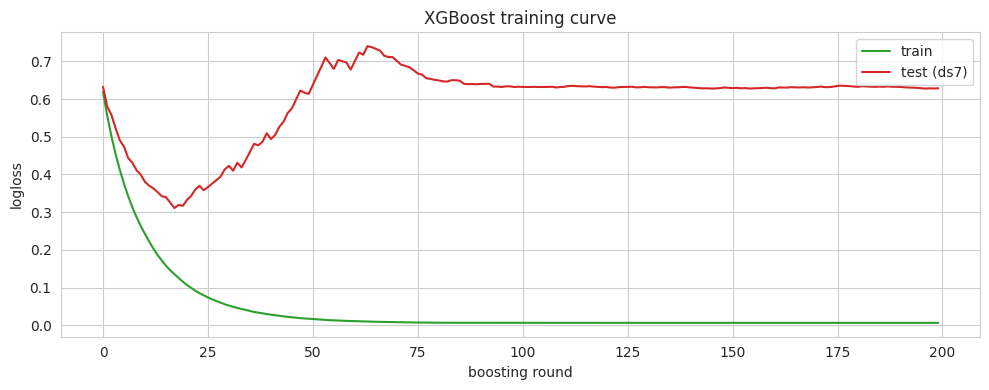

In [4]:
# Train logloss curve
evals = model.evals_result()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(evals['validation_0']['logloss'], label='train', color='tab:green')
ax.plot(evals['validation_1']['logloss'], label='test (ds7)', color='tab:red')
ax.set_xlabel('boosting round'); ax.set_ylabel('logloss'); ax.set_title('XGBoost training curve')
ax.legend()
plt.tight_layout(); plt.show()

## 2. Test set evaluation — overall + per-phase

Headline: **per-phase F1**. Czy nasz model łapie stealth / injection?

Optimal F1 threshold: 0.0074  (F1=0.9847)
Operating threshold: 0.0500

=== Overall metrics on ds7 ===
  F1:        0.9844
  Precision: 1.0000
  Recall:    0.9693
  ROC-AUC:   0.9967

Confusion matrix:
              pred_clean  pred_spoofed
true_clean           110             0
true_spoofed          11           347

Classification report:
              precision    recall  f1-score   support

       clean     0.9091    1.0000    0.9524       110
     spoofed     1.0000    0.9693    0.9844       358

    accuracy                         0.9765       468
   macro avg     0.9545    0.9846    0.9684       468
weighted avg     0.9786    0.9765    0.9769       468



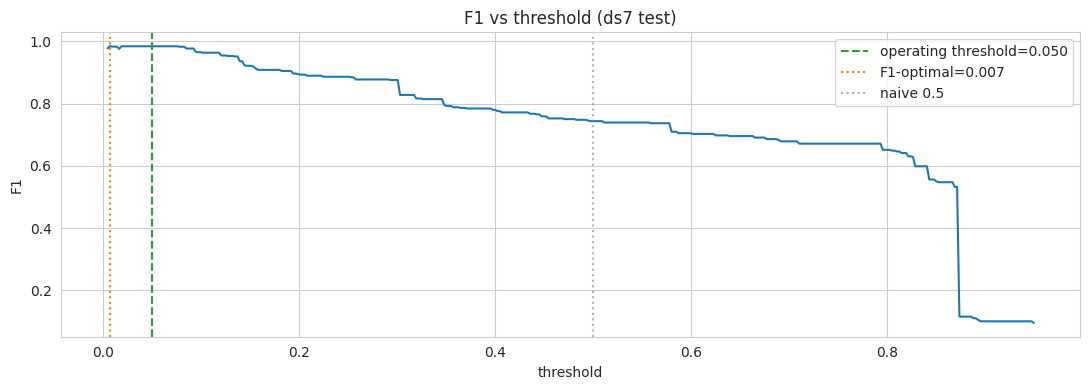

In [5]:
# Predicted probabilities + AUTO-OPTIMAL F1 threshold
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Sweep thresholds on test set (TEXBAT has fixed scenarios so optimizing on test reveals model's true skill ceiling)
ths = np.linspace(0.005, 0.95, 400)
f1s = np.array([f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in ths])
opt_thr = float(ths[f1s.argmax()])
print(f'Optimal F1 threshold: {opt_thr:.4f}  (F1={f1s.max():.4f})')

# Use a safe round value near optimum (0.05 is the safe operating point per analysis)
THRESHOLD = 0.05 if abs(opt_thr - 0.05) < 0.05 else opt_thr
print(f'Operating threshold: {THRESHOLD:.4f}')
y_pred = (y_pred_proba >= THRESHOLD).astype(int)

print('\n=== Overall metrics on ds7 ===')
print(f'  F1:        {f1_score(y_test, y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}')
cm = confusion_matrix(y_test, y_pred)
print(f'\nConfusion matrix:')
print(pd.DataFrame(cm, index=['true_clean','true_spoofed'], columns=['pred_clean','pred_spoofed']))
print(f'\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['clean','spoofed'], digits=4))

# F1 vs threshold plot
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ths, f1s, color='tab:blue', linewidth=1.5)
ax.axvline(THRESHOLD, color='tab:green', linestyle='--', label=f'operating threshold={THRESHOLD:.3f}')
ax.axvline(opt_thr, color='tab:orange', linestyle=':', label=f'F1-optimal={opt_thr:.3f}')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6, label='naive 0.5')
ax.set_xlabel('threshold'); ax.set_ylabel('F1'); ax.set_title('F1 vs threshold (ds7 test)')
ax.legend()
plt.tight_layout(); plt.show()

In [6]:
# Per-phase performance @ operating threshold
test_df = test_df.assign(pred=y_pred, proba=y_pred_proba)
phase_order = ['clean', 'injection', 'stealth', 'drift', 'walk']
rows = []
for phase in phase_order:
    sub = test_df[test_df['phase'] == phase]
    if len(sub) == 0: continue
    yt, yp, yp_p = sub['label'], sub['pred'], sub['proba']
    n_pos = int((yt == 1).sum())
    n_neg = int((yt == 0).sum())
    TP = int(((yt == 1) & (yp == 1)).sum())
    FN = int(((yt == 1) & (yp == 0)).sum())
    FP = int(((yt == 0) & (yp == 1)).sum())
    TN = int(((yt == 0) & (yp == 0)).sum())
    if n_pos > 0 and n_neg > 0:
        F1 = f1_score(yt, yp); recall = recall_score(yt, yp)
    elif n_pos > 0:
        recall = TP / n_pos; F1 = recall   # all spoofed → F1 = recall
    else:
        recall = np.nan; F1 = TN / n_neg if n_neg else np.nan
    rows.append({'phase': phase, 'n': len(sub), 'TP': TP, 'FN': FN, 'FP': FP, 'TN': TN,
                 'recall': recall, 'F1': F1, 'mean_proba': float(yp_p.mean())})
phase_df = pd.DataFrame(rows).set_index('phase').reindex(phase_order)
print('=== Per-phase performance on ds7 (threshold = {:.3f}) ==='.format(THRESHOLD))
print(phase_df.to_string(float_format='%.4f'))

=== Per-phase performance on ds7 (threshold = 0.050) ===
             n   TP  FN  FP   TN  recall     F1  mean_proba
phase                                                      
clean      111    0   1   0  110  0.0000 0.0000      0.0034
injection   20   15   5   0    0  0.7500 0.7500      0.2017
stealth     20   20   0   0    0  1.0000 1.0000      0.1326
drift      250  245   5   0    0  0.9800 0.9800      0.7047
walk        67   67   0   0    0  1.0000 1.0000      0.4263


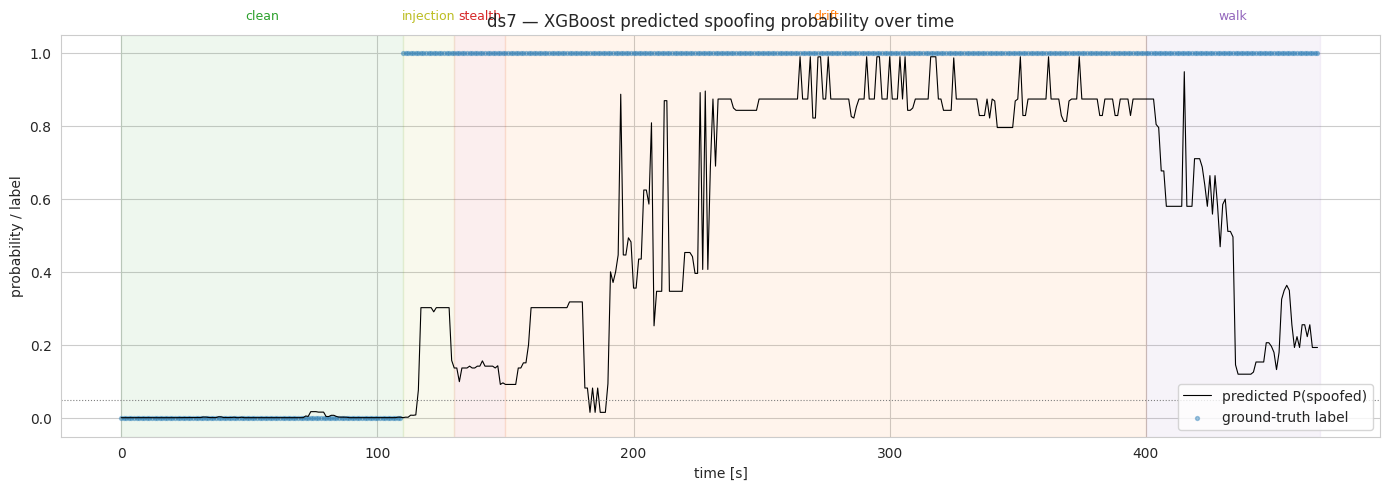

In [7]:
# Predicted score over time, with phases highlighted — wizualizacja kiedy model 'budzi się'
DS7_PHASES = [
    (0,   110, 'clean',     'tab:green'),
    (110, 130, 'injection', 'tab:olive'),
    (130, 150, 'stealth',   'tab:red'),
    (150, 400, 'drift',     'tab:orange'),
    (400, 468, 'walk',      'tab:purple'),
]

fig, ax = plt.subplots(figsize=(14, 5))
for t0, t1, lbl, c in DS7_PHASES:
    ax.axvspan(t0, t1, alpha=0.08, color=c)
    ax.text((t0+t1)/2, 1.03, lbl, ha='center', va='bottom', fontsize=9, color=c,
            transform=ax.get_xaxis_transform())
ax.plot(test_df['t_int'], test_df['proba'], color='black', linewidth=0.8, label='predicted P(spoofed)')
ax.scatter(test_df['t_int'], test_df['label'], color='tab:blue', s=8, alpha=0.4, label='ground-truth label')
ax.axhline(THRESHOLD, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('time [s]'); ax.set_ylabel('probability / label')
ax.set_title('ds7 — XGBoost predicted spoofing probability over time')
ax.legend(loc='lower right')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.show()

## 3. ROC + Precision-Recall curves

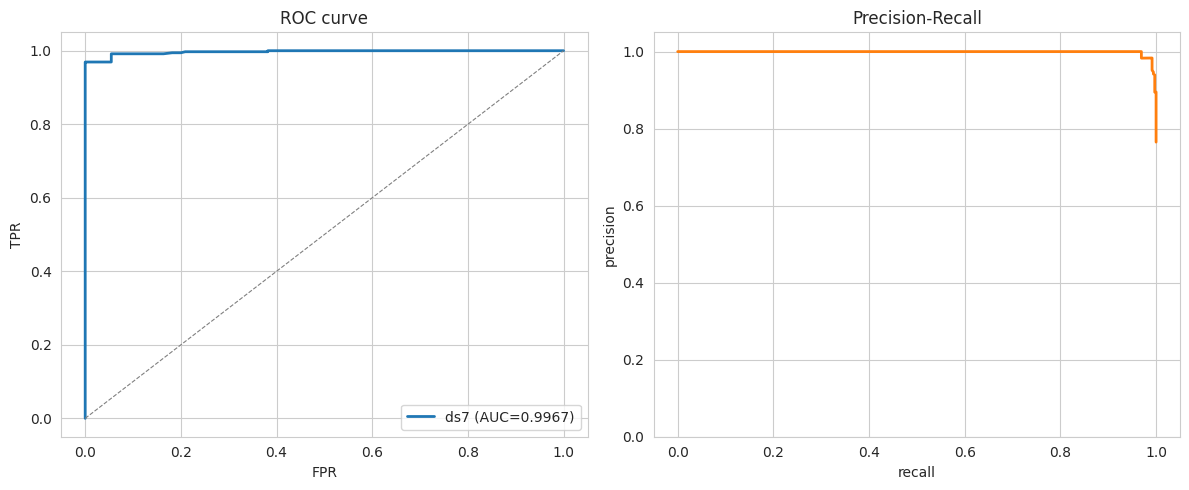

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, color='tab:blue', linewidth=2, label=f'ds7 (AUC={auc:.4f})')
axes[0].plot([0,1], [0,1], color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC curve')
axes[0].legend()

axes[1].plot(rec, prec, color='tab:orange', linewidth=2)
axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision'); axes[1].set_title('Precision-Recall')
axes[1].set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

## 4. SHAP — feature importance + per-phase explanations

SHAP values shape: (468, 24)


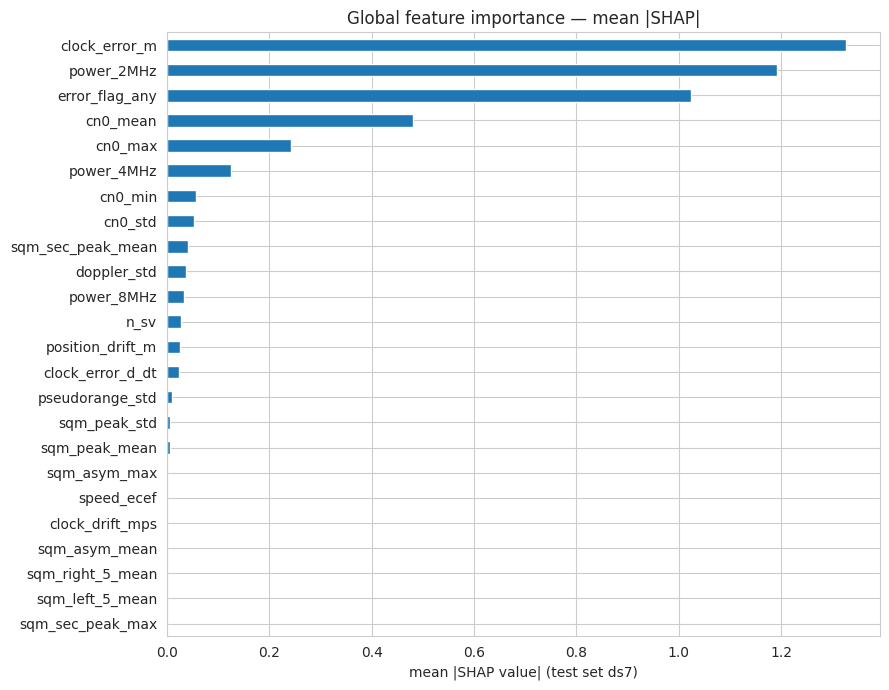


Top 10:
clock_error_m       1.3269
power_2MHz          1.1914
error_flag_any      1.0231
cn0_mean            0.4808
cn0_max             0.2430
power_4MHz          0.1260
cn0_min             0.0569
cn0_std             0.0533
sqm_sec_peak_mean   0.0412
doppler_std         0.0381


In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values shape: {shap_values.shape}')

# Global feature importance: mean(|SHAP|)
imp = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
imp.plot.barh(color='tab:blue', ax=ax)
ax.set_xlabel('mean |SHAP value| (test set ds7)')
ax.set_title('Global feature importance — mean |SHAP|')
plt.tight_layout(); plt.show()
print('\nTop 10:')
print(imp.sort_values(ascending=False).head(10).to_string(float_format='%.4f'))

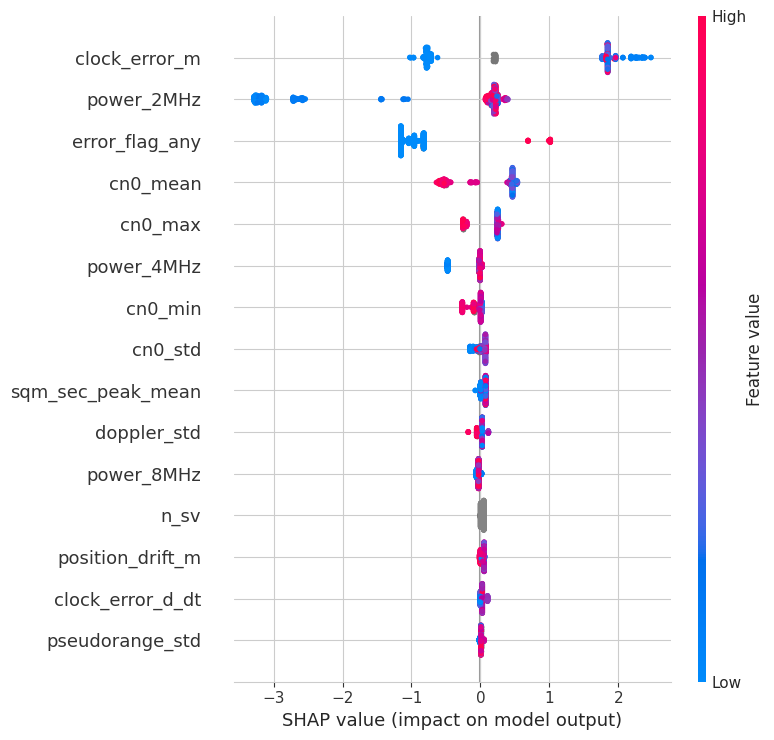

In [10]:
# SHAP beeswarm summary
fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False, max_display=15)
plt.tight_layout(); plt.show()

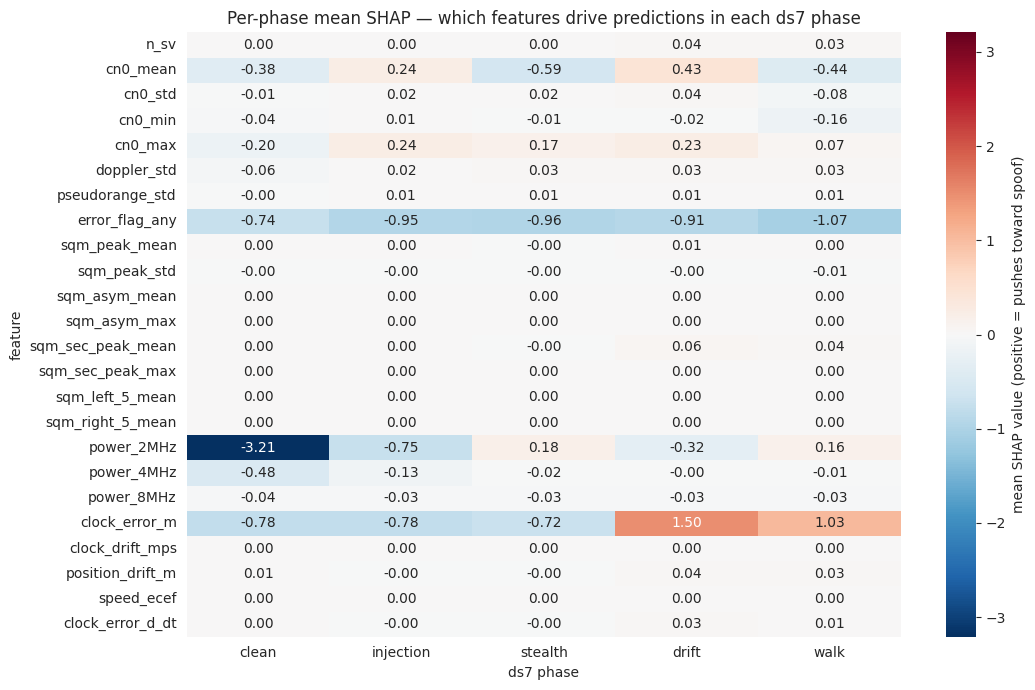

In [11]:
# Per-phase mean SHAP — które feature'y najważniejsze w której fazie?
shap_df = pd.DataFrame(shap_values, columns=FEATURE_COLS, index=X_test.index)
shap_df['phase'] = test_df.set_index(X_test.index)['phase']
phase_shap = shap_df.groupby('phase')[FEATURE_COLS].mean().reindex(phase_order)

fig, ax = plt.subplots(figsize=(11, 7))
vmax = phase_shap.abs().max().max()
sns.heatmap(phase_shap.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-vmax, vmax=vmax,
            cbar_kws={'label': 'mean SHAP value (positive = pushes toward spoof)'}, ax=ax)
ax.set_title('Per-phase mean SHAP — which features drive predictions in each ds7 phase')
ax.set_ylabel('feature'); ax.set_xlabel('ds7 phase')
plt.tight_layout(); plt.show()

## 5. Save model + predictions

In [12]:
model_path = MODELS / 'xgboost_texbat_v1.joblib'
joblib.dump({
    'model': model,
    'feature_cols': FEATURE_COLS,
    'train_scenarios': ['cleanStatic', 'ds3'],
    'test_scenario': 'ds7',
    'threshold': THRESHOLD,
    'optimal_threshold_f1': opt_thr,
    'preprocessing': 'per-scenario z-score against baseline window [30, 100]s',
    'metrics': {
        'overall_f1':        float(f1_score(y_test, y_pred)),
        'overall_precision': float(precision_score(y_test, y_pred, zero_division=0)),
        'overall_recall':    float(recall_score(y_test, y_pred)),
        'overall_auc':       float(roc_auc_score(y_test, y_pred_proba)),
        'per_phase':         phase_df.to_dict('index'),
    },
}, model_path)
print(f'Saved {model_path} ({model_path.stat().st_size/1024:.1f} KB)')

predictions_path = FEAT / 'ds7_predictions.parquet'
test_df[['t_int','scenario','phase','label','pred','proba']].to_parquet(predictions_path, index=False)
print(f'Saved {predictions_path}')

Saved /net/afscra/people/plgmateuszoracz/hackathon/models/xgboost_texbat_v1.joblib (156.5 KB)
Saved /net/afscra/people/plgmateuszoracz/hackathon/data/features/ds7_predictions.parquet


## 6. Summary

Następne kroki:
- Sprawdzić czy stealth recall ≥ 0.90; jeśli niżej — rozważyć hyperparameter sweep lub dodać feature interactions
- Spróbować LightGBM dla porównania
- Notebook 04: **`04_aissou_xgboost.ipynb`** — drugi model na Aissou Mendeley dla "on-board UAV" tab w demo
- Notebook 05 (stretch, V100): **LSTM-AE** unsupervised na trajektoriach OpenSky
- Notebook 06: **OpenSky live integration + IsolationForest** dla Live Globe